# Retail Sales Prediction: Modeling and Interpretation

This notebook loads a fresh copy of the raw dataset, performs pre-split cleaning only where safe, builds preprocessing pipelines, compares models, tunes a Random Forest, and interprets the final model.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    BEST_MODEL_PATH,
    DATA_DICTIONARY,
    FIGURES_DIR,
    PROCESSED_DATA_PATH,
    RANDOM_STATE,
    RAW_DATA_PATH,
    TARGET,
)
from src.data_loader import (
    basic_cleaning,
    load_raw_data,
    missing_value_report,
    restore_placeholders_to_null,
    save_processed_snapshot,
    summarize_numeric_columns,
)
from src.evaluation import evaluate_regression_model
from src.modeling import (
    build_linear_regression_pipeline,
    build_random_forest_pipeline,
    make_train_test_split,
    split_features_target,
    tune_random_forest,
)
from src.preprocessing import make_preprocessor
from src.visualization import (
    plot_correlation_heatmap,
    plot_linear_regression_coefficients,
    plot_model_comparison,
    plot_outlet_type_vs_sales,
    plot_rf_feature_importance,
    save_figure,
    set_plot_style,
)

pd.set_option("display.max_columns", 100)
set_plot_style()

## Fresh Data Load

In [2]:
raw_df = pd.read_csv(RAW_DATA_PATH)
print(raw_df.shape)
display(raw_df.head())

(8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Pre-Split Cleaning

To avoid data leakage, only duplicate removal and category standardization happen before splitting. Missing-value imputation is handled inside the scikit-learn preprocessing pipeline after the train-test split.

In [3]:
model_df = basic_cleaning(raw_df, fill_placeholders=False)

print(f"Duplicate rows after cleaning: {model_df.duplicated().sum():,}")
print(sorted(model_df["Item_Fat_Content"].dropna().unique()))
display(missing_value_report(model_df))

Duplicate rows after cleaning: 0
['Low Fat', 'Regular']


,missing_count,missing_percent
Outlet_Size,2410,28.28
Item_Weight,1463,17.17


## Feature and Target Split

In [4]:
X, y = split_features_target(model_df)
X_train, X_test, y_train, y_test = make_train_test_split(X, y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (6392, 10)
X_test: (2131, 10)
y_train: (6392,)
y_test: (2131,)


## Preprocessing Object

In [5]:
preprocessor = make_preprocessor(scale_numeric=True)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Linear Regression

In [6]:
linear_model = build_linear_regression_pipeline()
linear_model.fit(X_train, y_train)

linear_metrics = evaluate_regression_model(
    "Linear Regression", linear_model, X_train, y_train, X_test, y_test
)
display(linear_metrics.round(4))

,model,split,MAE,MSE,RMSE,R2
0,Linear Regression,Train,847.1289,1.297558e+06,1139.1041,0.5616
1,Linear Regression,Test,804.1204,1.194350e+06,1092.8631,0.5671


Linear Regression has train R-squared 0.5616 and test R-squared 0.5671. The two scores are close, so this model is not heavily overfit, but it underfits some of the nonlinear relationships in the data.

## Default Random Forest

In [7]:
default_rf = build_random_forest_pipeline(n_estimators=200)
default_rf.fit(X_train, y_train)

rf_metrics = evaluate_regression_model(
    "Random Forest", default_rf, X_train, y_train, X_test, y_test
)
display(rf_metrics.round(4))

,model,split,MAE,MSE,RMSE,R2
0,Random Forest,Train,295.0144,1.790844e+05,423.1837,0.9395
1,Random Forest,Test,768.8202,1.217311e+06,1103.3182,0.5588


The default Random Forest has train R-squared 0.9395 and test R-squared 0.5588. This large gap indicates overfitting. Its test score is also lower than Linear Regression, so tuning is needed before recommending a tree-based model.

## Tuned Random Forest

In [8]:
search = tune_random_forest(build_random_forest_pipeline(), X_train, y_train)
print("Best parameters:", search.best_params_)
print(f"Best cross-validation R2: {search.best_score_:.4f}")

best_params = {key.replace("model__", ""): value for key, value in search.best_params_.items()}
tuned_rf = build_random_forest_pipeline(**best_params)
tuned_rf.fit(X_train, y_train)

tuned_metrics = evaluate_regression_model(
    "Tuned Random Forest", tuned_rf, X_train, y_train, X_test, y_test
)
display(tuned_metrics.round(4))

Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best cross-validation R2: 0.5952


,model,split,MAE,MSE,RMSE,R2
0,Tuned Random Forest,Train,755.3945,1.152612e+06,1073.5977,0.6105
1,Tuned Random Forest,Test,728.3644,1.096396e+06,1047.0894,0.6026


,model,split,MAE,MSE,RMSE,R2
0,Linear Regression,Train,847.13,1297558.14,1139.10,0.5616
1,Linear Regression,Test,804.12,1194349.72,1092.86,0.5671
2,Random Forest,Train,295.01,179084.45,423.18,0.9395
3,Random Forest,Test,768.82,1217310.96,1103.32,0.5588
4,Tuned Random Forest,Train,755.39,1152612.12,1073.60,0.6105
5,Tuned Random Forest,Test,728.36,1096396.16,1047.09,0.6026


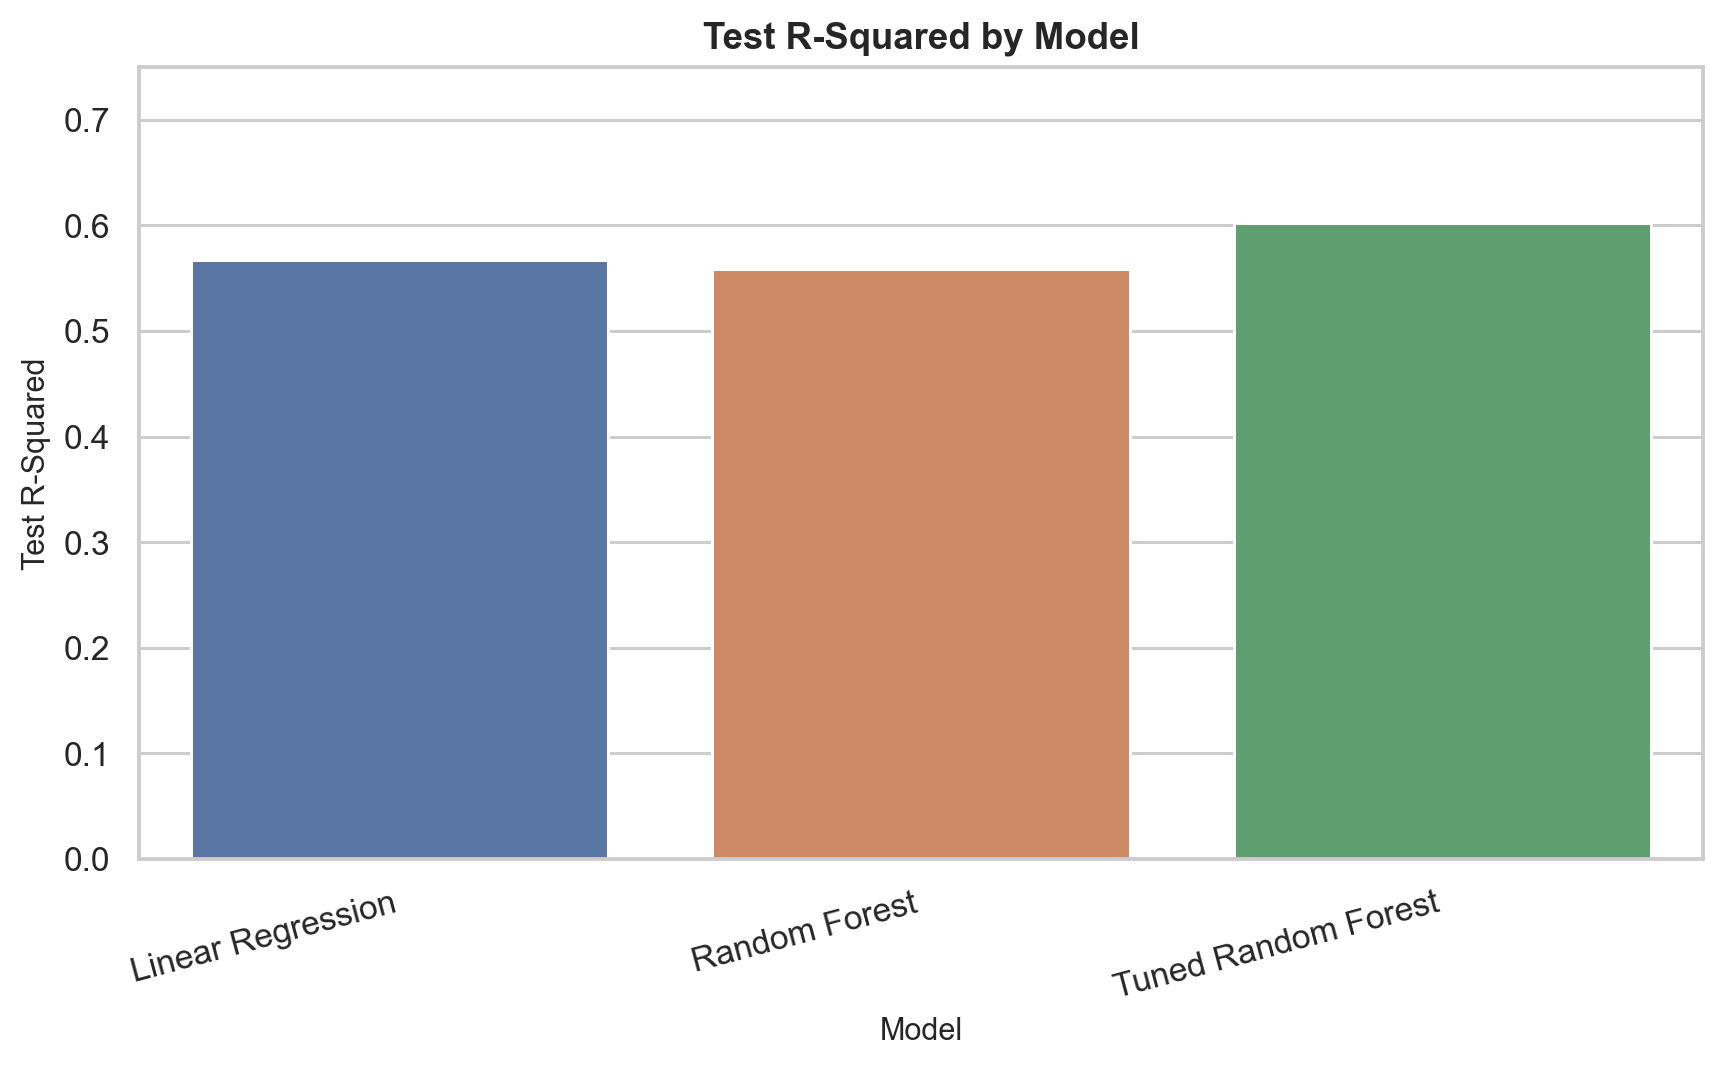

In [9]:
metrics_df = pd.concat([linear_metrics, rf_metrics, tuned_metrics], ignore_index=True)
metrics_df = metrics_df.round({"MAE": 2, "MSE": 2, "RMSE": 2, "R2": 4})
display(metrics_df)

metrics_df.to_csv(PROJECT_ROOT / "reports" / "model_metrics.csv", index=False)
plot_model_comparison(metrics_df, FIGURES_DIR / "model_comparison.png")
display(Image(filename=str(FIGURES_DIR / "model_comparison.png")))

The tuned Random Forest improved over the default Random Forest on the test set (0.6026 vs. 0.5588). The tuned model is the recommended model because it has the best test R-squared and the lowest RMSE among the compared models.

For a non-technical stakeholder: the tuned model explains about 60.3% of the variation in item sales on unseen data. I would also communicate RMSE ($1,047) because it describes the typical prediction error in the same sales units stakeholders understand.

## Linear Regression Coefficients

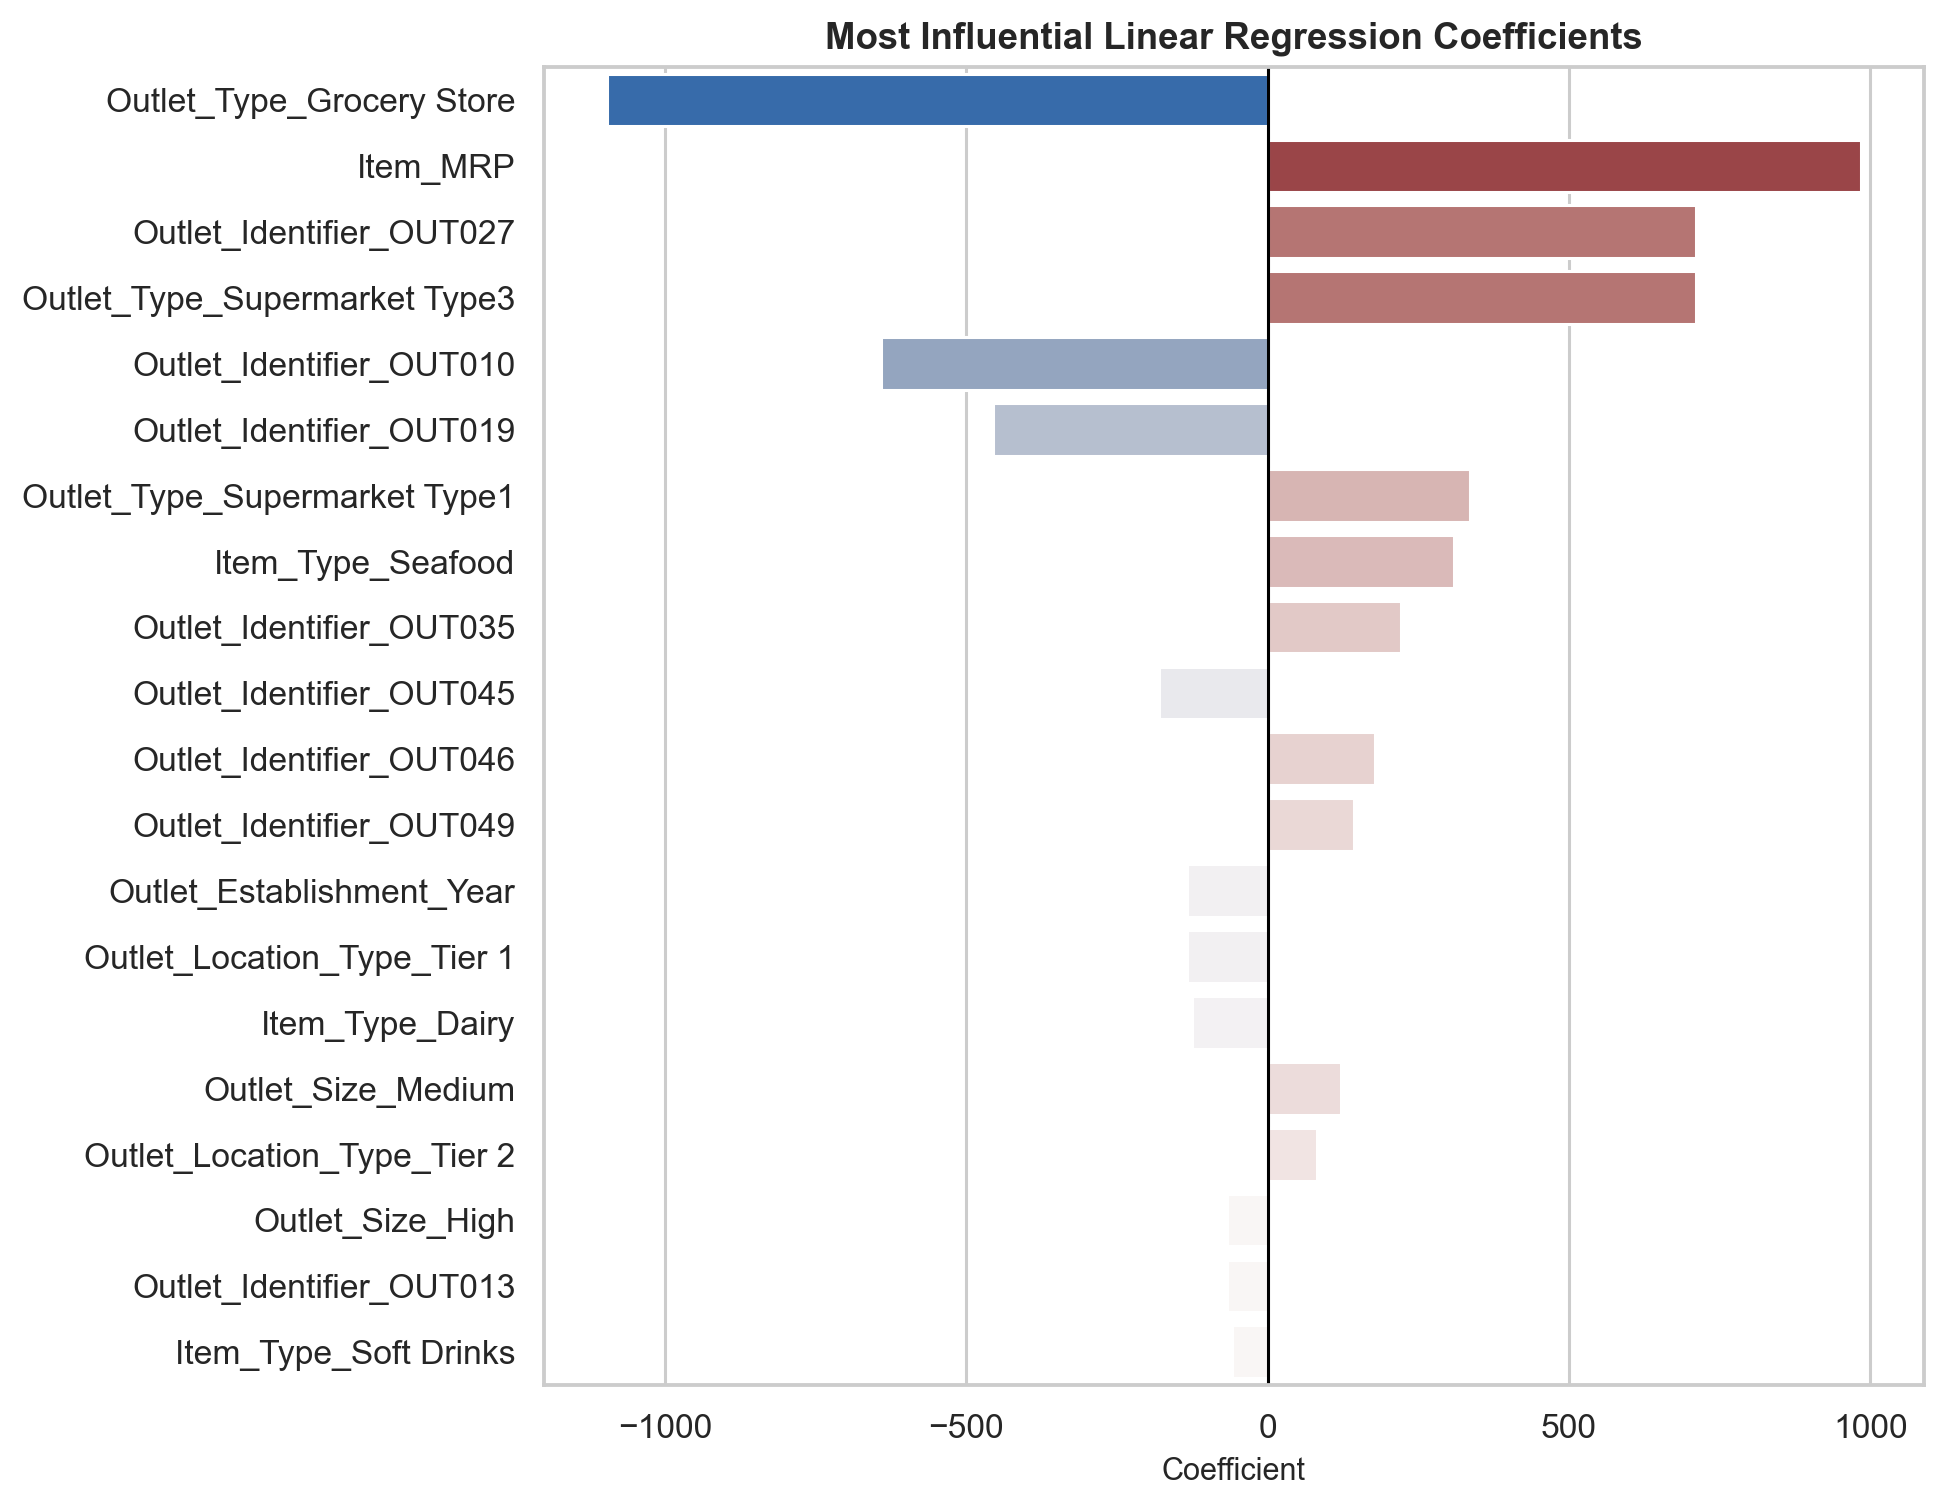

,feature,coefficient,abs_coefficient
38,Outlet_Type_Grocery Store,-1095.870536,1095.870536
2,Item_MRP,984.513074,984.513074
27,Outlet_Identifier_OUT027,710.857517,710.857517
41,Outlet_Type_Supermarket Type3,710.857517,710.857517
22,Outlet_Identifier_OUT010,-640.860332,640.860332
26,Outlet_Identifier_OUT019,-455.010204,455.010204
39,Outlet_Type_Supermarket Type1,336.746605,336.746605
18,Item_Type_Seafood,308.888596,308.888596
28,Outlet_Identifier_OUT035,221.582083,221.582083
29,Outlet_Identifier_OUT045,-180.537637,180.537637


In [10]:
coef_df = plot_linear_regression_coefficients(
    linear_model, FIGURES_DIR / "linreg_coefficients.png"
)
display(Image(filename=str(FIGURES_DIR / "linreg_coefficients.png")))
display(coef_df.head(10))

Top coefficient interpretation:

- `Outlet_Type_Grocery Store` has the strongest negative coefficient, meaning grocery store outlets are associated with much lower predicted sales than the baseline store type.
- `Item_MRP` has a strong positive coefficient, meaning higher-priced items tend to generate higher sales.
- `Outlet_Identifier_OUT027` has a strong positive coefficient, suggesting that this specific outlet performs above the baseline after preprocessing.

## Tree-Based Feature Importances

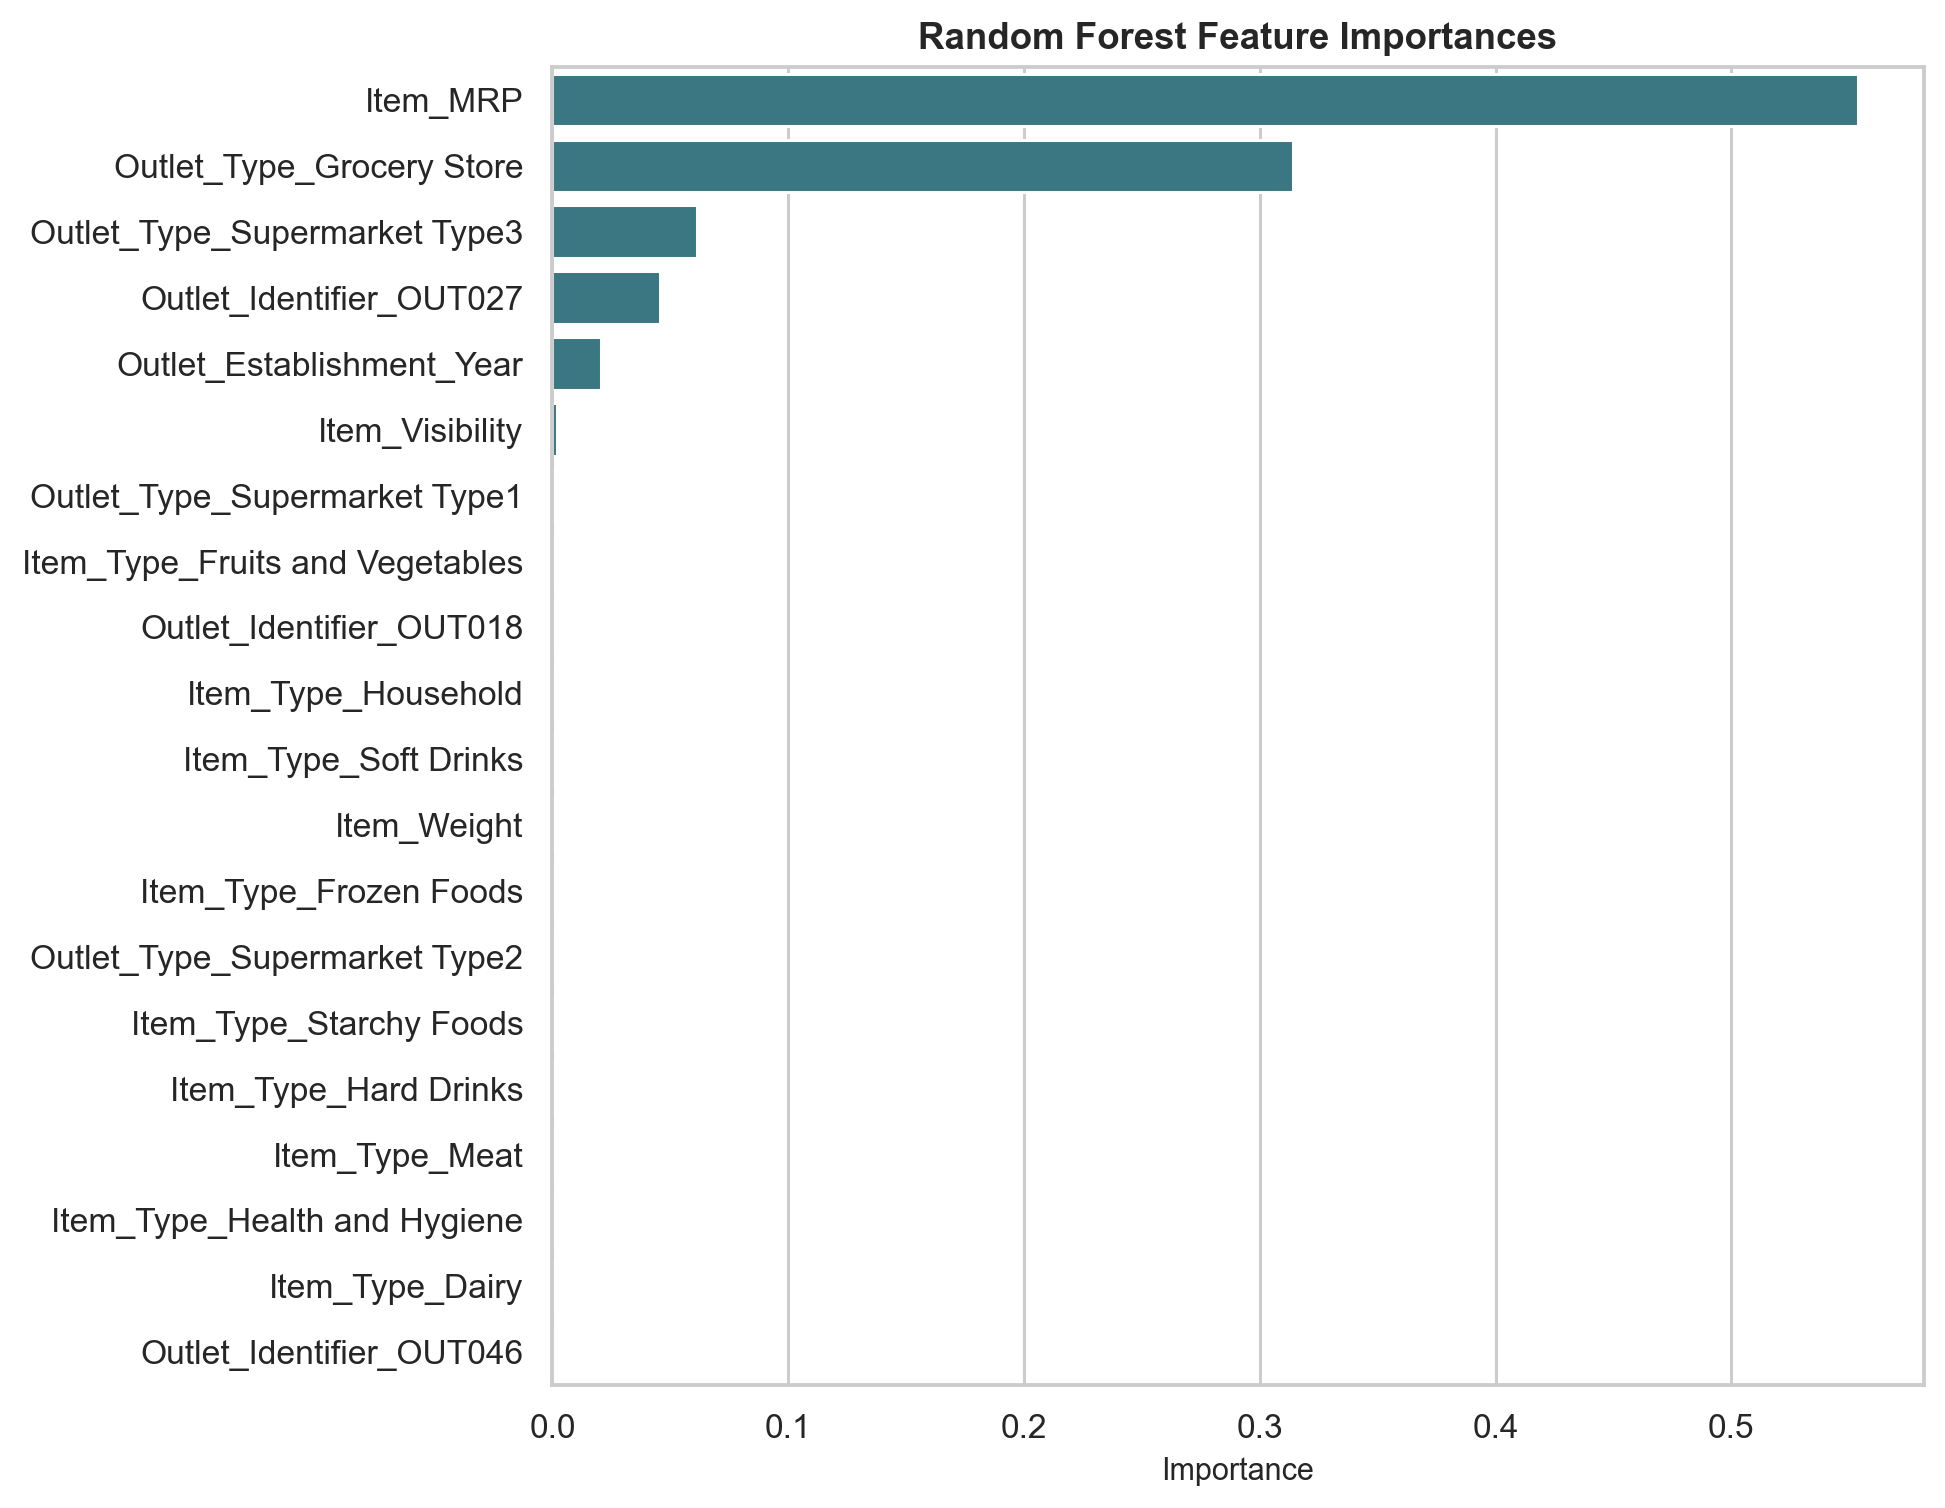

,feature,importance
2,Item_MRP,0.553838
38,Outlet_Type_Grocery Store,0.313940
41,Outlet_Type_Supermarket Type3,0.061384
27,Outlet_Identifier_OUT027,0.045695
3,Outlet_Establishment_Year,0.020751
1,Item_Visibility,0.001988
39,Outlet_Type_Supermarket Type1,0.000458
12,Item_Type_Fruits and Vegetables,0.000233
25,Outlet_Identifier_OUT018,0.000226
15,Item_Type_Household,0.000182


In [11]:
importance_df = plot_rf_feature_importance(
    tuned_rf, FIGURES_DIR / "rf_feature_importance.png"
)
display(Image(filename=str(FIGURES_DIR / "rf_feature_importance.png")))
display(importance_df.head(10))

Top Random Forest feature interpretation:

- `Item_MRP` is the most important feature, showing that listed price is the strongest driver of predicted sales.
- `Outlet_Type_Grocery Store` is highly important, reinforcing that grocery outlets behave differently from supermarkets.
- `Outlet_Type_Supermarket Type3`, `Outlet_Identifier_OUT027`, and `Outlet_Establishment_Year` indicate that store format and store identity/history matter for sales prediction.

## Save Final Model

In [12]:
import joblib

joblib.dump(tuned_rf, BEST_MODEL_PATH)
print(f"Saved final tuned model to: {BEST_MODEL_PATH}")

Saved final tuned model to: C:\Users\MSI\Desktop\project\Prediction-of-Product-Sales\models\best_rf_model.joblib


## Stakeholder Recommendation

I recommend using the tuned Random Forest for sales forecasting because it provides the strongest test-set performance while reducing the overfitting seen in the default forest. From a business perspective, the retailer should pay close attention to item price, store format, and high-performing outlet patterns when planning assortment, placement, and sales forecasts.